In [4]:
import numpy as np


def qudit_qft(d: int, inverse: bool = False) -> np.ndarray:
    """
    Return the QFT matrix for a single qudit of dimension d.

    For inverse=False:
        F[j, k] = exp(2πi * j * k / d) / sqrt(d)

    For inverse=True:
        F†[j, k] = exp(-2πi * j * k / d) / sqrt(d)

    Args:
        d: qudit dimension (d >= 2)
        inverse: whether to return the inverse QFT

    Returns:
        A (d, d) complex numpy array.
    """
    if d < 2:
        raise ValueError("d must be at least 2")

    omega = np.exp((-2j if inverse else 2j) * np.pi / d)
    j = np.arange(d).reshape((d, 1))
    k = np.arange(d).reshape((1, d))

    return omega ** (j * k) / np.sqrt(d)


def n_qudit_qft(d: int, n: int, inverse: bool = False) -> np.ndarray:
    """
    Return the QFT matrix on n qudits, dimension d^n x d^n.

    This is just F_d^{⊗ n}.

    Args:
        d: qudit dimension
        n: number of qudits
        inverse: whether to return the inverse QFT

    Returns:
        A (d**n, d**n) complex numpy array.
    """
    if n < 1:
        raise ValueError("n must be at least 1")

    F = qudit_qft(d, inverse=inverse)
    out = F.copy()
    for _ in range(n - 1):
        out = np.kron(out, F)
    return out


def is_unitary(U: np.ndarray, atol: float = 1e-10) -> bool:
    """
    Check whether U is unitary.
    """
    I = np.eye(U.shape[0], dtype=complex)
    return np.allclose(U.conj().T @ U, I, atol=atol)

d = 8
F1 = qudit_qft(d)
print(F1)

[[ 0.35355339+0.j          0.35355339+0.j          0.35355339+0.j
   0.35355339+0.j          0.35355339+0.j          0.35355339+0.j
   0.35355339+0.j          0.35355339+0.j        ]
 [ 0.35355339+0.j          0.25      +0.25j        0.        +0.35355339j
  -0.25      +0.25j       -0.35355339+0.j         -0.25      -0.25j
  -0.        -0.35355339j  0.25      -0.25j      ]
 [ 0.35355339+0.j          0.        +0.35355339j -0.35355339+0.j
  -0.        -0.35355339j  0.35355339+0.j          0.        +0.35355339j
  -0.35355339+0.j         -0.        -0.35355339j]
 [ 0.35355339+0.j         -0.25      +0.25j       -0.        -0.35355339j
   0.25      +0.25j       -0.35355339+0.j          0.25      -0.25j
   0.        +0.35355339j -0.25      -0.25j      ]
 [ 0.35355339+0.j         -0.35355339+0.j          0.35355339+0.j
  -0.35355339+0.j          0.35355339+0.j         -0.35355339+0.j
   0.35355339+0.j         -0.35355339+0.j        ]
 [ 0.35355339+0.j         -0.25      -0.25j        0.    

In [7]:
import numpy as np
from typing import Sequence


def int_to_digits(value: int, base: int, width: int) -> np.ndarray:
    """
    Convert an integer to a base-'base' digit vector of fixed length 'width'.

    Uses big-endian ordering:
        digits[0] is the most significant qudit.
    """
    if value < 0:
        raise ValueError("value must be nonnegative")

    digits = np.zeros(width, dtype=int)
    for i in range(width - 1, -1, -1):
        digits[i] = value % base
        value //= base
    return digits


def digits_to_int(digits: Sequence[int], base: int) -> int:
    """
    Convert a base-'base' digit vector to an integer.

    Assumes big-endian ordering.
    """
    out = 0
    for digit in digits:
        out = out * base + int(digit)
    return out


def dot_mod(x: Sequence[int], s: Sequence[int], d: int) -> int:
    """
    Compute modular dot product sum_j x_j * s_j mod d.
    """
    x = np.asarray(x, dtype=int)
    s = np.asarray(s, dtype=int)
    if x.shape != s.shape:
        raise ValueError("x and s must have the same shape")
    return int(np.sum(x * s) % d)


def bv_oracle_unitary(hidden: Sequence[int], d: int) -> np.ndarray:
    """
    Build the standard reversible Bernstein-Vazirani oracle for qudits:

        U_f |x>|y> = |x>|y + s·x mod d>

    where:
        hidden = s = [s_0, ..., s_{n-1}]
        x is an n-qudit input register
        y is a 1-qudit target register

    Args:
        hidden: hidden string / ket labels, entries in {0, ..., d-1}
        d: qudit dimension

    Returns:
        U: complex permutation matrix of shape (d^(n+1), d^(n+1))
    """
    hidden = np.asarray(hidden, dtype=int)

    if d < 2:
        raise ValueError("d must be at least 2")
    if hidden.ndim != 1 or len(hidden) == 0:
        raise ValueError("hidden must be a nonempty 1D sequence")
    if np.any(hidden < 0) or np.any(hidden >= d):
        raise ValueError("hidden entries must lie in {0, ..., d-1}")

    n = len(hidden)
    dim_in = d ** n
    dim_total = d ** (n + 1)

    U = np.zeros((dim_total, dim_total), dtype=complex)

    for x_index in range(dim_in):
        x_digits = int_to_digits(x_index, d, n)
        fx = dot_mod(x_digits, hidden, d)

        for y in range(d):
            in_digits = np.concatenate([x_digits, [y]])
            in_index = digits_to_int(in_digits, d)

            y_out = (y + fx) % d
            out_digits = np.concatenate([x_digits, [y_out]])
            out_index = digits_to_int(out_digits, d)

            U[out_index, in_index] = 1.0

    return U


def bv_phase_oracle_unitary(hidden: Sequence[int], d: int) -> np.ndarray:
    """
    Build the phase oracle for qudit Bernstein-Vazirani:

        O_s |x> = omega^(s·x) |x>
        omega = exp(2πi / d)

    Args:
        hidden: hidden string / ket labels
        d: qudit dimension

    Returns:
        O: diagonal unitary of shape (d^n, d^n)
    """
    hidden = np.asarray(hidden, dtype=int)

    if d < 2:
        raise ValueError("d must be at least 2")
    if hidden.ndim != 1 or len(hidden) == 0:
        raise ValueError("hidden must be a nonempty 1D sequence")
    if np.any(hidden < 0) or np.any(hidden >= d):
        raise ValueError("hidden entries must lie in {0, ..., d-1}")

    n = len(hidden)
    dim = d ** n
    omega = np.exp(2j * np.pi / d)

    diag = np.zeros(dim, dtype=complex)
    for x_index in range(dim):
        x_digits = int_to_digits(x_index, d, n)
        fx = dot_mod(x_digits, hidden, d)
        diag[x_index] = omega ** fx

    return np.diag(diag)


def is_unitary(U: np.ndarray, atol: float = 1e-10) -> bool:
    """
    Check if U is unitary.
    """
    I = np.eye(U.shape[0], dtype=complex)
    return np.allclose(U.conj().T @ U, I, atol=atol)


d = 3
hidden = [1]

U = bv_oracle_unitary(hidden, d)
O = bv_phase_oracle_unitary(hidden, d)

print(O)

[[ 1. +0.j         0. +0.j         0. +0.j       ]
 [ 0. +0.j        -0.5+0.8660254j  0. +0.j       ]
 [ 0. +0.j         0. +0.j        -0.5-0.8660254j]]


Initial state |0>:
[1.+0.j 0.+0.j 0.+0.j]

After QFT:
[0.57735027+0.j 0.57735027+0.j 0.57735027+0.j]

After phase oracle:
[ 0.57735027+0.j  -0.28867513-0.5j -0.28867513+0.5j]

Final state after inverse QFT:
[1.66533454e-16+1.66533454e-16j 1.11022302e-16+1.38777878e-16j
 1.00000000e+00+0.00000000e+00j]

Measurement probabilities:
[5.54667824e-32 3.15852511e-32 1.00000000e+00]

Most likely outcome: 2


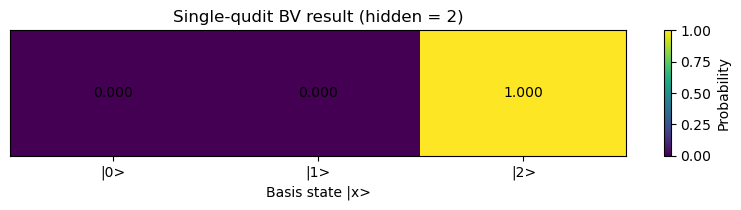

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def qudit_qft(d: int, inverse: bool = False) -> np.ndarray:
    """
    QFT on a single qudit of dimension d.

    For inverse=False:
        F[j, k] = exp(2πi * j * k / d) / sqrt(d)

    For inverse=True:
        F†[j, k] = exp(-2πi * j * k / d) / sqrt(d)
    """
    if d < 2:
        raise ValueError("d must be at least 2")

    omega = np.exp((-2j if inverse else 2j) * np.pi / d)
    j = np.arange(d).reshape((d, 1))
    k = np.arange(d).reshape((1, d))
    return omega ** (j * k) / np.sqrt(d)


def single_qudit_phase_oracle(hidden: int, d: int) -> np.ndarray:
    """
    Phase oracle for single-qudit BV:

        O_s |x> = omega^(s*x) |x>

    where hidden = s in {0, ..., d-1}.
    """
    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0 <= hidden < d):
        raise ValueError("hidden must be in {0, ..., d-1}")

    omega = np.exp(2j * np.pi / d)
    phases = np.array([omega ** (hidden * x) for x in range(d)], dtype=complex)
    return np.diag(phases)


def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state


def run_single_qudit_bv(hidden: int, d: int):
    """
    Run the full single-qudit Bernstein-Vazirani circuit:

        |0> -- F -- O_s -- F† -- measure

    Returns:
        psi0          initial state
        psi_after_qft state after QFT
        psi_after_orc state after oracle
        psi_final     final state
        probs         measurement probabilities
    """
    F = qudit_qft(d, inverse=False)
    F_dag = qudit_qft(d, inverse=True)
    O_s = single_qudit_phase_oracle(hidden, d)

    psi0 = basis_state(0, d)
    psi_after_qft = F @ psi0
    psi_after_orc = O_s @ psi_after_qft
    psi_final = F_dag @ psi_after_orc

    probs = np.abs(psi_final) ** 2
    return psi0, psi_after_qft, psi_after_orc, psi_final, probs


def plot_probabilities_imshow(probs: np.ndarray, hidden: int):
    """
    Plot final measurement probabilities with imshow.
    """
    fig, ax = plt.subplots(figsize=(8, 2.2))
    im = ax.imshow(probs.reshape(1, -1), aspect="auto")

    ax.set_title(f"Single-qudit BV result (hidden = {hidden})")
    ax.set_xlabel("Basis state |x>")
    ax.set_yticks([])
    ax.set_xticks(np.arange(len(probs)))
    ax.set_xticklabels([f"|{i}>" for i in range(len(probs))])

    for i, p in enumerate(probs):
        ax.text(i, 0, f"{p:.3f}", ha="center", va="center")

    plt.colorbar(im, ax=ax, label="Probability")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Example: qutrit with hidden value s = 2
    d = 3
    hidden = 2

    psi0, psi1, psi2, psi_final, probs = run_single_qudit_bv(hidden, d)

    print("Initial state |0>:")
    print(psi0)
    print("\nAfter QFT:")
    print(psi1)
    print("\nAfter phase oracle:")
    print(psi2)
    print("\nFinal state after inverse QFT:")
    print(psi_final)
    print("\nMeasurement probabilities:")
    print(probs)
    print("\nMost likely outcome:", np.argmax(probs))

    plot_probabilities_imshow(probs, hidden)